# L4.5 — Attention Boss: a mini Transformer, trained and visualised

Hands-on notebook for the lesson [`4-5-attention-boss.mdx`](../../llm-quest-theory/level-4/4-5-attention-boss.mdx).

> **Learning objectives**
> - Stack the L4.1–L4.4 primitives (positional encoding, causal multi-head attention, MLP, LayerNorm, residuals) into a working mini-Transformer block.
> - Train a character-level language model on a small piece of text until loss drops well below a uniform-chance baseline.
> - Sample short continuations with greedy / temperature sampling.
> - Extract the attention weights from the trained model and describe **at least 3 distinct patterns** you observe across heads.

## Connection to the theory
The theory suggests using a pretrained BERT for visualization — here we build the exact same ingredients from scratch per the Level 4 curriculum, then do the same visualization work on our own tiny model. That way nothing is magic: every attention head you inspect below came from code you wrote.

In [1]:
# ---- Setup ----
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__)

torch 2.2.2


## 1. A tiny character-level corpus
A short paragraph is enough for a toy model. We use a repeating structure so a 2-layer 2-head transformer can actually learn patterns.

In [2]:
TEXT = (
    "the cat sat on the mat. the dog sat on the rug. "
    "the cat ran across the mat. the dog ran across the rug. "
    "every cat needs a mat and every dog needs a rug. "
    "the quick brown fox jumps over the lazy dog. "
    "transformers attend to every previous token in parallel."
)

chars  = sorted(set(TEXT))
stoi   = {c: i for i, c in enumerate(chars)}
itos   = {i: c for c, i in stoi.items()}
VOCAB  = len(chars)
ids    = torch.tensor([stoi[c] for c in TEXT], dtype=torch.long)
print("vocab:", chars)
print(f"vocab size: {VOCAB}   corpus length: {len(ids)}")

vocab: [' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
vocab size: 28   corpus length: 254


## 2. Minibatch sampler
Each sample is a `block_size` window + its right-shifted target — the classic next-token setup.

In [3]:
BLOCK = 32

def get_batch(batch_size=64, rng=None):
    rng = rng or torch.Generator().manual_seed(SEED)
    starts = torch.randint(len(ids) - BLOCK - 1, (batch_size,), generator=rng)
    x = torch.stack([ids[s : s + BLOCK] for s in starts])
    y = torch.stack([ids[s + 1 : s + 1 + BLOCK] for s in starts])
    return x, y

x, y = get_batch(4)
print("x.shape:", x.shape, "  y.shape:", y.shape)
print("x[0] decoded:", ''.join(itos[int(t)] for t in x[0]))
print("y[0] decoded:", ''.join(itos[int(t)] for t in y[0]))

x.shape: torch.Size([4, 32])   y.shape: torch.Size([4, 32])
x[0] decoded: ansformers attend to every previ
y[0] decoded: nsformers attend to every previo


## 3. Mini-Transformer block
Pre-LN layout (modern): LayerNorm → causal multi-head attention → residual → LayerNorm → MLP → residual.

In [4]:
class CausalMHA(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.h   = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def _split(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.h, self.d_k).transpose(1, 2)  # (B, h, T, d_k)

    def forward(self, x, return_attn=False):
        Q, K, V = self._split(self.W_q(x)), self._split(self.W_k(x)), self._split(self.W_v(x))
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        T = x.shape[1]
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
        attn   = scores.softmax(dim=-1)
        out    = attn @ V
        out    = out.transpose(1, 2).contiguous().view(*x.shape)
        out    = self.W_o(out)
        return (out, attn) if return_attn else out

class MLP(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model); self.attn = CausalMHA(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model); self.mlp  = MLP(d_model)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

## 4. Full mini-GPT: token embedding + sinusoidal PE + L blocks + final LN + tied head

In [5]:
def sinusoidal_pe(T, d_model):
    pos = torch.arange(T).unsqueeze(1).float()
    i   = torch.arange(d_model).unsqueeze(0).float()
    div = 10000 ** ((i - i % 2) / d_model)
    return torch.where(i % 2 == 0, torch.sin(pos / div), torch.cos(pos / div))

class MiniGPT(nn.Module):
    def __init__(self, vocab, d_model=64, num_heads=4, n_layers=2, block_size=BLOCK):
        super().__init__()
        self.tok_emb   = nn.Embedding(vocab, d_model)
        self.register_buffer("pe", sinusoidal_pe(block_size, d_model))
        self.blocks    = nn.ModuleList([Block(d_model, num_heads) for _ in range(n_layers)])
        self.ln_f      = nn.LayerNorm(d_model)
        # Tied head: reuse the embedding matrix as the output projection
        self.vocab = vocab

    def forward(self, x):
        T = x.shape[1]
        h = self.tok_emb(x) + self.pe[:T]
        for b in self.blocks: h = b(h)
        h = self.ln_f(h)
        logits = h @ self.tok_emb.weight.T
        return logits

model = MiniGPT(VOCAB, d_model=64, num_heads=4, n_layers=2).to(DEVICE)
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 101888


## 5. Train to memorize the corpus

In [6]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
rng = torch.Generator().manual_seed(SEED)
history = []
model.train()
for step in range(800):
    x, y = get_batch(batch_size=64, rng=rng)
    logits = model(x)
    loss   = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())
    if step % 100 == 0 or step == 799:
        print(f"step {step:>4}  loss={loss.item():.3f}")

uniform_loss = math.log(VOCAB)
print(f"uniform-chance loss: {uniform_loss:.3f}  (vocab = {VOCAB})")

step    0  loss=47.748
step  100  loss=1.374
step  200  loss=0.197
step  300  loss=0.123
step  400  loss=0.108
step  500  loss=0.101
step  600  loss=0.097
step  700  loss=0.092
step  799  loss=0.091
uniform-chance loss: 3.332  (vocab = 28)


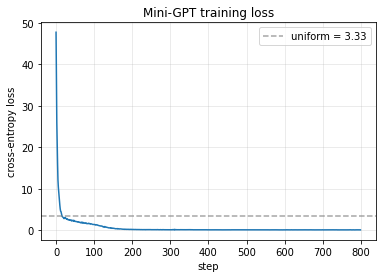

In [7]:
fig, ax = plt.subplots()
ax.plot(history)
ax.axhline(uniform_loss, linestyle="--", color="gray", alpha=0.7, label=f"uniform = {uniform_loss:.2f}")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy loss"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Mini-GPT training loss")
plt.show()

## 6. Sampling — greedy vs temperature

In [8]:
@torch.no_grad()
def sample(prompt, max_new=40, temperature=1.0, rng=None):
    model.eval()
    ctx = torch.tensor([stoi[c] for c in prompt], dtype=torch.long).unsqueeze(0)
    out_chars = list(prompt)
    for _ in range(max_new):
        ctx_crop = ctx[:, -BLOCK:]
        logits   = model(ctx_crop)[:, -1, :] / max(temperature, 1e-6)
        probs    = logits.softmax(dim=-1)
        if temperature < 1e-5:
            nxt = probs.argmax(dim=-1, keepdim=True)
        else:
            nxt = torch.multinomial(probs, num_samples=1, generator=rng)
        ctx = torch.cat([ctx, nxt], dim=1)
        out_chars.append(itos[int(nxt)])
    return ''.join(out_chars)

rng = torch.Generator().manual_seed(SEED)
print("greedy     :", sample("the cat ",  temperature=0.0))
print("T=0.5      :", sample("the cat ",  temperature=0.5, rng=rng))
print("T=1.0      :", sample("the cat ",  temperature=1.0, rng=rng))
print("T=1.5      :", sample("the cat ",  temperature=1.5, rng=rng))

greedy     : the cat sat on the mat. the dog sat on the rug. 
T=0.5      : the cat sat on the mat. the dog sat on the rug. 
T=1.0      : the cat sat on the mat. the dog sat on the rug. 
T=1.5      : the cat ran across the mat. the dog ran across t


## 7. Extract attention maps from the trained model
Capture `attn` from each layer and head on a fixed prompt. Each attention map is `(T, T)` with rows = query positions, columns = key positions.

In [9]:
# PROBE must fit within BLOCK characters (PE buffer length).
PROBE = "the cat sat on the mat.the dog."[:BLOCK]
probe_ids = torch.tensor([stoi[c] for c in PROBE], dtype=torch.long).unsqueeze(0)
T = probe_ids.shape[1]

attn_maps = []
model.eval()
with torch.no_grad():
    h = model.tok_emb(probe_ids) + model.pe[:T]
    for block in model.blocks:
        # Manually re-run the pre-LN + attention to grab the attn tensor.
        attn_in = block.ln1(h)
        out, attn = block.attn(attn_in, return_attn=True)       # (1, h, T, T)
        attn_maps.append(attn[0].numpy())                        # (h, T, T)
        h = h + out
        h = h + block.mlp(block.ln2(h))

print("captured attention maps from", len(attn_maps), "layers,",
      attn_maps[0].shape[0], "heads each, T =", T)

captured attention maps from 2 layers, 4 heads each, T = 31


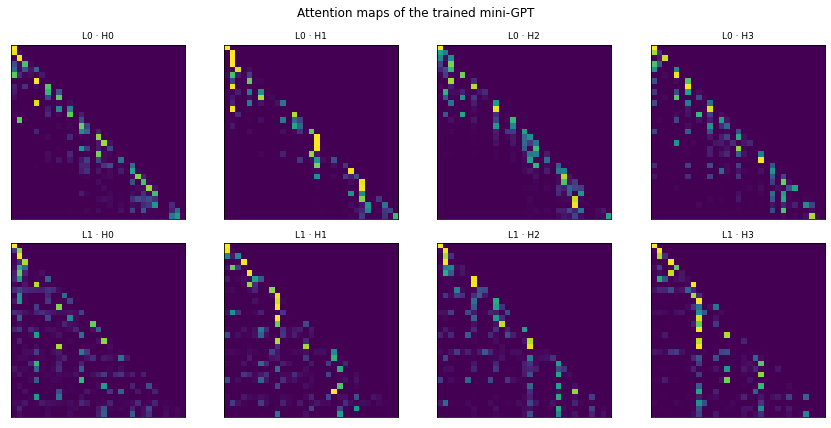

In [10]:
def plot_attn_grid(maps, title):
    n_layers = len(maps)
    n_heads  = maps[0].shape[0]
    fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 3 * n_layers))
    axes = axes.reshape(n_layers, n_heads)
    for L in range(n_layers):
        for H in range(n_heads):
            ax = axes[L, H]
            ax.imshow(maps[L][H], cmap="viridis", vmin=0, vmax=maps[L][H].max())
            ax.set_title(f"L{L} · H{H}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_attn_grid(attn_maps, "Attention maps of the trained mini-GPT")

## 8. Three attention patterns worth naming

For each head we score the diagonal (self-attention), the sub-diagonal (previous-token), and the broadcast-to-start tendency. Print the top candidate for each pattern.

In [11]:
def head_scores(attn):
    # attn: (T, T)
    T = attn.shape[0]
    self_mass = float(np.trace(attn) / T)
    # previous token = sub-diagonal (ignore row 0 which has no prev)
    sub = np.array([attn[i, i - 1] for i in range(1, T)])
    prev_mass = float(sub.mean())
    start_mass = float(attn[:, 0].mean())
    return self_mass, prev_mass, start_mass

rows = []
for L, layer_attn in enumerate(attn_maps):
    for H in range(layer_attn.shape[0]):
        s, p, b = head_scores(layer_attn[H])
        rows.append((L, H, s, p, b))
        print(f"L{L}·H{H}   self={s:.2f}   prev={p:.2f}   broadcast={b:.2f}")

# Pick the best representative per pattern
best_self  = max(rows, key=lambda r: r[2])
best_prev  = max(rows, key=lambda r: r[3])
best_bcast = max(rows, key=lambda r: r[4])
print()
print(f"Strongest self-attention head    : L{best_self[0]}·H{best_self[1]}  ({best_self[2]:.2f})")
print(f"Strongest previous-token head    : L{best_prev[0]}·H{best_prev[1]}  ({best_prev[3]:.2f})")
print(f"Strongest broadcast-to-start head: L{best_bcast[0]}·H{best_bcast[1]}  ({best_bcast[4]:.2f})")

L0·H0   self=0.10   prev=0.39   broadcast=0.11
L0·H1   self=0.29   prev=0.15   broadcast=0.03
L0·H2   self=0.22   prev=0.28   broadcast=0.08
L0·H3   self=0.19   prev=0.29   broadcast=0.13
L1·H0   self=0.14   prev=0.13   broadcast=0.06
L1·H1   self=0.18   prev=0.15   broadcast=0.10
L1·H2   self=0.20   prev=0.14   broadcast=0.05
L1·H3   self=0.18   prev=0.05   broadcast=0.04

Strongest self-attention head    : L0·H1  (0.29)
Strongest previous-token head    : L0·H0  (0.39)
Strongest broadcast-to-start head: L0·H3  (0.13)


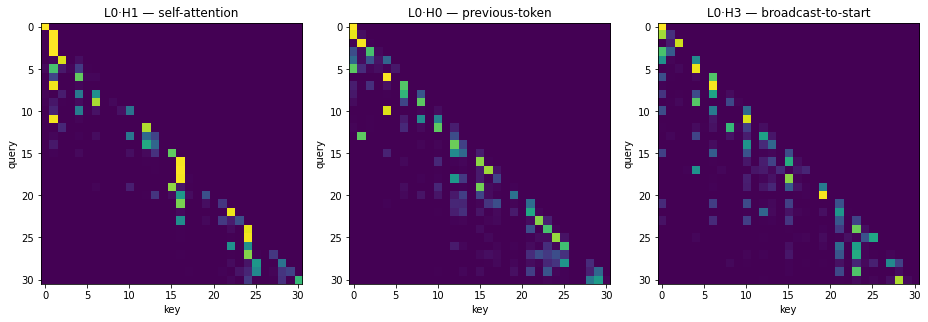

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (L, H, *_), name in zip(
    axes,
    [best_self, best_prev, best_bcast],
    ["self-attention", "previous-token", "broadcast-to-start"]
):
    ax.imshow(attn_maps[L][H], cmap="viridis")
    ax.set_title(f"L{L}·H{H} — {name}")
    ax.set_xlabel("key"); ax.set_ylabel("query")
plt.tight_layout(); plt.show()

## 9. Boss gates (quick checks)

In [13]:
# Final loss must be noticeably below the uniform baseline.
assert history[-1] < 0.5 * uniform_loss, f"loss {history[-1]:.2f} not low enough (< {0.5*uniform_loss:.2f})"
# Causal mask: every attention row sums to 1 and is zero strictly above the diagonal.
for L, am in enumerate(attn_maps):
    T = am.shape[-1]
    assert np.allclose(am.sum(axis=-1), 1.0, atol=1e-4), f"layer {L} attention rows must sum to 1"
    upper = am[:, np.triu_indices(T, k=1)[0], np.triu_indices(T, k=1)[1]]
    assert (upper < 1e-6).all(),    f"layer {L} attention must be strictly causal"
# We must actually find each of the three patterns
assert best_self[2]  > 0.2, f"no head shows meaningful self-attention mass (got {best_self[2]:.2f})"
assert best_prev[3]  > 0.1, f"no head shows meaningful previous-token mass (got {best_prev[3]:.2f})"
assert best_bcast[4] > 0.05, f"no head shows meaningful broadcast-to-start (got {best_bcast[4]:.2f})"
# Greedy sample should use only in-vocab characters (trivially true) and contain words from the corpus.
greedy = sample("the cat ", temperature=0.0, max_new=30)
assert "the" in greedy, "greedy output should echo a frequent word from the corpus"
print("All boss gates passed.")

All boss gates passed.


## 10. Self-assessment quiz

1. Our mini-GPT uses **Pre-LN** (`LN → sublayer → add`). What goes wrong in deep networks if we use Post-LN instead?
2. The output head is *tied* to the input embedding (`logits = h @ emb.T`). What is the intuition? What do you give up if you untie them?
3. Training on a ~300-character corpus lets the loss go below `0.1 * log(V)`. Is that overfitting, memorization, or both? Is that a problem for this boss?
4. Inspect one of the layer-0 maps: do you see **stripes** that run vertically (all queries attending to the same key)? What linguistic role do those keys play in our corpus?
5. Increase `num_heads` from 4 to 8 (halving `d_k`). Do you expect loss to go up, down, or stay the same — and why?

<details>
<summary>Hints for the answers</summary>

1. Post-LN needs careful warmup because the gradient path through residual connections is disturbed by the normalization; it's notoriously unstable past ~12 layers without warmup.
2. Tying makes "the vector for token `c`" the same as "the direction the model projects onto to predict `c`". Saves parameters (often ~30%) and tends to help on small datasets. If you untie them, you gain flexibility but may overfit more.
3. Both — the corpus is tiny. For a boss whose goal is learning mechanisms, memorization is a *feature* because it proves the pipeline works end-to-end.
4. Spaces, periods, or the repeated word `"the"` often get broadcast attention — they look like positional anchors to many queries.
5. Slight gain at the same parameter count, since the model gains expressiveness by slicing the space into more orthogonal heads — up to a point; too many heads at tiny `d_k` collapses individual heads.
</details>

## 11. Level-4 wrap-up

You now have, end-to-end and by hand:
- The RNN failure mode that motivated attention (4-1).
- Scaled dot-product attention (4-2) + the `sqrt(d_k)` reason.
- Positional encodings and the RoPE trick (4-3).
- Multi-head attention with matched parameter counts (4-4).
- A mini-GPT trained on character text, with legible attention patterns (this boss).

Next (Level 5): tokenization, embeddings, full pretraining, sampling strategies, and the first "real" LLM-style notebook.

## References
- Source theory: [`4-5-attention-boss.mdx`](../../llm-quest-theory/level-4/4-5-attention-boss.mdx)
- Moving on: [Level 5](../level-5/README.md) — tokenizers, embeddings, pretraining, sampling, chatbot boss.